In [4]:
#NOTE: raw data only on julia's laptop; use the matrix from repo 
import os

path = "/home/jgersey/SageBat"

audio_file = os.path.join(path, "20260414_100939.wav")
#print(audio_file)

# matrix shape parameters -- change these to build a different-sized matrix
N_TIME_FRAMES = 15000   # matrix rows: time frames / n_samples
N_FREQ_BINS = 484      # matrix columns: freq bins / n_features
DURATION_S = 600.0     # expected clip length in seconds (10 min files)

## Building the (`N_TIME_FRAMES` × `N_FREQ_BINS`) matrix for sparse-representation code

`N_TIME_FRAMES` (rows) = `n_samples`, `N_FREQ_BINS` (cols) = `n_features` — the
standard `(n_samples, n_features)` shape sparse-coding APIs expect (e.g.
scikit-learn's `DictionaryLearning`/`SparseCoder`). Each row is one time frame;
its columns are that frame's frequency feature vector.

**Why not just trim the clip shorter?** Trimming doesn't fix anything — the
problem isn't the clip's length, it's that a 384 kHz recording has vastly more
raw samples than the matrix has cells, at any duration. To fit the raw waveform
into a small fixed matrix you'd have to either split it into many chunks (no
single matrix per file), or downsample it — and downsampling to fit would drop
the effective rate below 20 kHz, erasing the ultrasonic bat chirps (20-100+ kHz)
this mic exists to record. So trimming duration doesn't help, and downsampling
isn't an option.

**Spectrogram instead.** A mel-spectrogram is lossy too, but the *right* kind:
we choose to compress frequency resolution (via mel binning) while keeping the
full native Nyquist range (`fmax = sr/2`, no resampling before the FFT), so bat
calls stay inside the analysis window. Shape is directly controllable —
`hop_length` sets the row count, `n_mels` sets the column count — so one file
maps to exactly one `(N_TIME_FRAMES, N_FREQ_BINS)` matrix, no data thrown away.

**Remaining trade-off:** `DURATION_S / N_TIME_FRAMES` seconds of time
resolution per row (120 ms at the current settings) — chirps landing in the
same row get merged in time. That's inherent to fitting the clip into a fixed
number of rows, not something a different transform avoids.


In [6]:
import numpy as np
import librosa

def wav_to_fixed_spectrogram_matrix(
    audio_path,
    duration=DURATION_S,          # expected clip length in seconds
    n_time_frames=N_TIME_FRAMES,  # target n_samples (rows)
    n_freq_bins=N_FREQ_BINS,      # target n_features (cols)
    window_s=0.5,                 # analysis window length per row, seconds
    fmin=1000,                    # Hz, cut very-low-frequency noise/wind
    db_range=80.0,
):
    """
    Native-rate (no resampling) mel-spectrogram, shaped to exactly
    (n_time_frames, n_freq_bins) — i.e. (n_samples, n_features), the
    convention jeongmin's sparse-coding algorithm expects — so a
    384kHz file maps to one fixed-size matrix without throwing away the
    ultrasonic band. Each row is spaced `duration / n_time_frames` seconds
    apart, built from a `window_s`-second analysis window; its columns are
    that window's mel/frequency feature vector.

    Returns
    -------
    spec : np.ndarray, shape (n_time_frames, n_freq_bins), float32 in [0, 1]
    mel_freqs : np.ndarray, center freq (Hz) of each column
    """
    sr = librosa.get_samplerate(audio_path)
    fmax = sr / 2  # keep full native Nyquist range (no ultrasonic content thrown away)

    # hop_length chosen so the clip maps to exactly n_time_frames rows;
    # n_fft set directly from window_s (analysis window per row)
    hop_length = int((sr * duration) // n_time_frames)
    n_fft = int(round(window_s * sr))

    data, _ = librosa.load(audio_path, sr=sr, mono=True, duration=duration)
    n_samples = int(duration * sr)
    if len(data) < n_samples:
        data = np.pad(data, (0, n_samples - len(data)))

    S = librosa.feature.melspectrogram(
        y=data, sr=sr,
        n_fft=n_fft, hop_length=hop_length,
        n_mels=n_freq_bins, fmin=fmin, fmax=fmax,
        window="hann",
    )  # (n_freq_bins, time_frames)

    # librosa's centering can produce a frame off by one; force exact shape
    if S.shape[1] > n_time_frames:
        S = S[:, :n_time_frames]
    elif S.shape[1] < n_time_frames:
        S = np.pad(S, ((0, 0), (0, n_time_frames - S.shape[1])))

    S_db = librosa.power_to_db(S, ref=np.max, top_db=db_range)
    spec = ((S_db + db_range) / db_range).astype(np.float32)

    mel_freqs = librosa.mel_frequencies(n_mels=n_freq_bins, fmin=fmin, fmax=fmax)
    return spec.T, mel_freqs  # (n_samples, n_features) = (n_time_frames, n_freq_bins)


In [7]:
matrix, freqs = wav_to_fixed_spectrogram_matrix(
    audio_file, duration=DURATION_S, n_time_frames=N_TIME_FRAMES, n_freq_bins=N_FREQ_BINS,
)

print(f"{audio_file}")
print(f"matrix shape: {matrix.shape}  (rows=samples/time frames, cols=features/freq bins)")
print(f"freq range: {freqs[0]:.0f} - {freqs[-1]:.0f} Hz (native Nyquist)")
print(f"value range: [{matrix.min():.3f}, {matrix.max():.3f}]")

/home/jgersey/SageBat/20260414_100939.wav
matrix shape: (15000, 484)  (rows=samples/time frames, cols=features/freq bins)
freq range: 1000 - 192000 Hz (native Nyquist)
value range: [0.410, 1.000]


In [8]:
# known bat chirp in audio_file, from field annotation
chirp_center_s = 289.85
chirp_window_s = 0.25

# which rows of the fixed (N_TIME_FRAMES, N_FREQ_BINS) matrix cover the chirp window?
row_duration_s = DURATION_S / matrix.shape[0]  # seconds/row (matches hop_length)
start_t, end_t = chirp_center_s - chirp_window_s / 2, chirp_center_s + chirp_window_s / 2
row_start, row_end = int(start_t // row_duration_s), int(end_t // row_duration_s)

print(f"chirp window: {start_t:.3f}-{end_t:.3f}s")
print(f"row duration: {row_duration_s * 1000:.0f} ms/row")
print(f"-> falls in matrix rows {row_start}-{row_end} ({row_end - row_start + 1} rows)")

chirp_rows = matrix[row_start:row_end + 1]
print(f"chirp rows value range: [{chirp_rows.min():.3f}, {chirp_rows.max():.3f}]  (whole-matrix mean: {matrix.mean():.3f})")

chirp window: 289.725-289.975s
row duration: 40 ms/row
-> falls in matrix rows 7243-7249 (7 rows)
chirp rows value range: [0.444, 0.886]  (whole-matrix mean: 0.611)


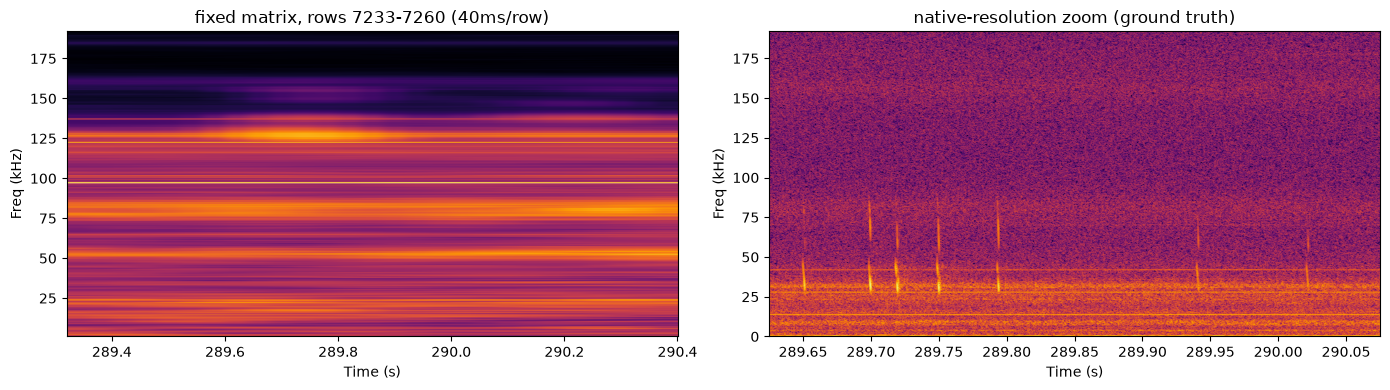

In [9]:
from matplotlib import pyplot as plt

# left: the chirp as it lands in the fixed (N_TIME_FRAMES, N_FREQ_BINS) matrix,
# with a few rows of context on each side
context_rows = 10
lo = max(0, row_start - context_rows)
hi = min(matrix.shape[0], row_end + 1 + context_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(
    matrix[lo:hi].T, aspect="auto", origin="lower", cmap="inferno",
    extent=[lo * row_duration_s, hi * row_duration_s, freqs[0] / 1000, freqs[-1] / 1000],
)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Freq (kHz)")
axes[0].set_title(f"fixed matrix, rows {lo}-{hi} ({row_duration_s * 1000:.0f}ms/row)")

# right: native-resolution (384kHz) ground-truth spectrogram over the same
# window, for comparison against what the fixed matrix actually captured
pad = 0.1
hi_data, hi_sr = librosa.load(audio_file, sr=None, mono=True, offset=start_t - pad, duration=(end_t - start_t) + 2 * pad)
S_hi = librosa.stft(hi_data, n_fft=1024, hop_length=64)
S_hi_db = librosa.amplitude_to_db(np.abs(S_hi), ref=np.max)
t_hi = librosa.frames_to_time(np.arange(S_hi.shape[1]), sr=hi_sr, hop_length=64) + (start_t - pad)
f_hi = librosa.fft_frequencies(sr=hi_sr, n_fft=1024)

axes[1].pcolormesh(t_hi, f_hi / 1000, S_hi_db, shading="gouraud", cmap="inferno")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Freq (kHz)")
axes[1].set_title("native-resolution zoom (ground truth)")

plt.tight_layout()
plt.show()

shape: (15000, 484)   dtype: float32   size: 29.0 MB
min=0.410  max=1.000  mean=0.611  std=0.094  median=0.636
fraction of cells < 0.05: 0.0%
fraction of cells < 0.1: 0.0%
fraction of cells < 0.2: 0.0%

most active row (time frame): 8935  (mean=0.630)
most active col (freq bin):   243  (14085 Hz, mean=0.834)


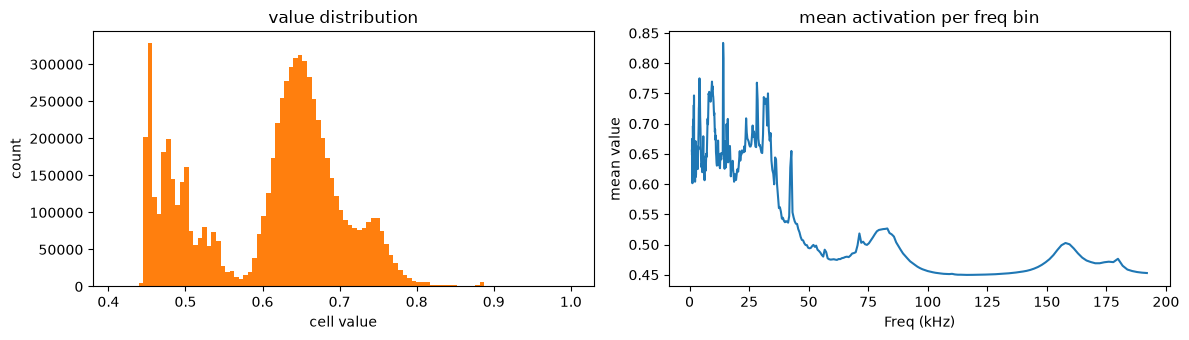

In [10]:
print(f"shape: {matrix.shape}   dtype: {matrix.dtype}   size: {matrix.nbytes / 1e6:.1f} MB")
print(f"min={matrix.min():.3f}  max={matrix.max():.3f}  mean={matrix.mean():.3f}  "
      f"std={matrix.std():.3f}  median={np.median(matrix):.3f}")

for thresh in (0.05, 0.1, 0.2):
    frac = (matrix < thresh).mean()
    print(f"fraction of cells < {thresh}: {frac:.1%}")

row_energy = matrix.mean(axis=1)   # avg activation per time frame
col_energy = matrix.mean(axis=0)   # avg activation per freq bin
print(f"\nmost active row (time frame): {row_energy.argmax()}  (mean={row_energy.max():.3f})")
print(f"most active col (freq bin):   {col_energy.argmax()}  ({freqs[col_energy.argmax()]:.0f} Hz, mean={col_energy.max():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(matrix.ravel(), bins=100, color="tab:orange")
axes[0].set_title("value distribution")
axes[0].set_xlabel("cell value")
axes[0].set_ylabel("count")

axes[1].plot(freqs / 1000, col_energy)
axes[1].set_title("mean activation per freq bin")
axes[1].set_xlabel("Freq (kHz)")
axes[1].set_ylabel("mean value")

plt.tight_layout()
plt.show()


In [11]:
# save the matrix (not the raw .wav, which is gitignored) so it can be committed
matrix_dir = os.path.join(path, "matrices")
os.makedirs(matrix_dir, exist_ok=True)

clip_name = os.path.splitext(os.path.basename(audio_file))[0]
matrix_path = os.path.join(matrix_dir, f"{clip_name}.npz")
np.savez_compressed(matrix_path, matrix=matrix, freqs=freqs)

print(f"saved to {matrix_path}  ({os.path.getsize(matrix_path) / 1e6:.2f} MB)")


saved to /home/jgersey/SageBat/matrices/20260414_100939.npz  (22.45 MB)
